# SmoothGrad Explanations for MCI Classification on NNConv model

In [1]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from torch_geometric.data import Data
from torch_geometric.nn import global_mean_pool, global_max_pool
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Mounted at /content/drive
Using device: cpu


### Model definition

In [4]:
class NNConvLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, out_dim):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, node_dim * out_dim)
        )
        self.node_dim = node_dim
        self.out_dim  = out_dim
        self.gru = nn.GRUCell(out_dim, node_dim)

    def forward(self, x, edge_index, edge_attr):
        src, dst = edge_index
        num_nodes = x.size(0)
        W     = self.edge_mlp(edge_attr).view(-1, self.node_dim, self.out_dim)
        h_src = x[src].unsqueeze(1)
        msg   = torch.bmm(h_src, W).squeeze(1)
        agg   = torch.zeros(num_nodes, self.out_dim, device=x.device)
        agg.scatter_add_(0, dst.unsqueeze(-1).expand_as(msg), msg)
        return self.gru(agg, x)


class NNConvNet(nn.Module):
    def __init__(self, node_in, edge_in, hidden, dropout):
        super().__init__()
        self.input_proj = nn.Linear(node_in, hidden)
        self.input_norm = nn.BatchNorm1d(hidden)
        self.conv1 = NNConvLayer(hidden, edge_in, hidden)
        self.norm1 = nn.BatchNorm1d(hidden)
        self.conv2 = NNConvLayer(hidden, edge_in, hidden)
        self.norm2 = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.input_proj(x)
        x = self.input_norm(x)
        x = x.relu()
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = x.relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = x.relu()
        x = self.dropout(x)
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        return self.classifier(x)

print('Model classes defined.')

Model classes defined.


### Load data and model

In [5]:
MODEL_PATH = '/content/drive/MyDrive/team3_xai_gnn/nnconv_results/outer_checkpoints/cfg00_outer1.pt'
TEST_PATH  = '/content/drive/MyDrive/team3_xai_gnn/preprocessed/fold_1_test.pt'
DMRI_PATH  = '/content/drive/MyDrive/team3_xai_gnn/oasis3_graphmls_scale1'

NODE_FEATURE_NAMES = ['volume', 'thickness', 'has_volume', 'has_thickness']
OUTCOME_COLORS     = {'TP': '#d62728', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#9467bd'}
CLASS_NAMES        = {0: 'CN', 1: 'MCI'}

model = NNConvNet(node_in=4, edge_in=15, hidden=32, dropout=0.3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print('Model loaded.')

Model loaded.


In [6]:
test_graphs = torch.load(TEST_PATH, map_location=device, weights_only=False)
print(f'Test subjects: {len(test_graphs)}')

graphml_files = sorted([f for f in os.listdir(DMRI_PATH) if f.endswith('.graphml')])
sample_G      = nx.read_graphml(os.path.join(DMRI_PATH, graphml_files[0]))
sample_G.remove_edges_from(list(nx.selfloop_edges(sample_G)))
nodes       = list(sample_G.nodes(data=True))
node_labels = {i: attrs.get('dn_name', f'node_{i}').strip()
               for i, (_, attrs) in enumerate(nodes)}
print(f'Node label map built: {len(node_labels)} ROIs')

Test subjects: 127
Node label map built: 124 ROIs


### SmoothGrad function

In [7]:
def run_smoothgrad(
    subject,
    target_class,
    n_samples   = 100,
    noise_level = 0.1,
):
    '''
    Computes SmoothGrad attributions for a single subject

    Parameters
    subject      : PyG Data object
    target_class : int - 0 = CN, 1 = MCI (always use predicted class)
    n_samples    : int - number of noisy forward passes to average over
                   100 gives stable results; increase to 200 if needed
    noise_level  : float - noise std as fraction of each feature's std
                   0.1 is standard; too high distorts attribution,
                   too low doesn't smooth enough

    Returns
    attr_signed  : np.ndarray (num_nodes, 4) - mean signed gradients
                   positive = feature pushes toward target_class
                   negative = feature pushes away from target_class
    attr_sq      : np.ndarray (num_nodes, 4) - mean squared gradients
                   (SmoothGrad² variant - always positive, better for ranking)
    '''
    model.eval()
    subject = subject.to(device)
    batch   = torch.zeros(subject.x.size(0), dtype=torch.long, device=device)
    x_orig  = subject.x.detach()   # (num_nodes, 4)

    # per-feature noise scale: noise_level × std of each feature across nodes
    feat_std   = x_orig.std(dim=0).clamp(min=1e-6)   # (4,)
    noise_std  = noise_level * feat_std               # (4,)

    grads_list = []
    for _ in range(n_samples):
        # add independent Gaussian noise to each feature dimension
        noise   = torch.randn_like(x_orig) * noise_std
        x_noisy = (x_orig + noise).requires_grad_(True)

        logits = model(x_noisy, subject.edge_index, subject.edge_attr, batch)
        logits[0, target_class].backward()

        grads_list.append(x_noisy.grad.detach().cpu())
        model.zero_grad()

    grads     = torch.stack(grads_list)   # (n_samples, num_nodes, 4)
    attr_signed = grads.mean(dim=0).numpy()          # signed mean
    attr_sq     = (grads ** 2).mean(dim=0).numpy()   # SmoothGrad^2 - always positive

    return attr_signed, attr_sq


def get_prediction(g):
    '''
    Returns (pred_class, prob_cn, prob_mci) for a single graph
    '''
    model.eval()
    g     = g.to(device)
    batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(g.x, g.edge_index, g.edge_attr, batch)
        probs  = torch.softmax(logits, dim=-1)
        pred   = logits.argmax(dim=-1).item()
    return pred, probs[0, 0].item(), probs[0, 1].item()


print('SmoothGrad function ready.')
print('Using SmoothGrad² (squared gradients) for node/feature importance ranking.')
print('Using signed SmoothGrad for directionality plots.')

SmoothGrad function ready.
Using SmoothGrad² (squared gradients) for node/feature importance ranking.
Using signed SmoothGrad for directionality plots.


### Find most confidently classified subjects per outcome

In [8]:
results = []
for g in test_graphs:
    pred, prob_cn, prob_mci = get_prediction(g)
    true = g.y.item()
    results.append((g, true, pred, prob_mci))

TP = sorted([(g,t,p,s) for g,t,p,s in results if t==1 and p==1], key=lambda x: -x[3])
TN = sorted([(g,t,p,s) for g,t,p,s in results if t==0 and p==0], key=lambda x:  x[3])
FP = sorted([(g,t,p,s) for g,t,p,s in results if t==0 and p==1], key=lambda x: -x[3])
FN = sorted([(g,t,p,s) for g,t,p,s in results if t==1 and p==0], key=lambda x:  x[3])

print(f'TP: {len(TP)}  TN: {len(TN)}  FP: {len(FP)}  FN: {len(FN)}')
for tag, pool in [('TP',TP),('TN',TN),('FP',FP),('FN',FN)]:
    if pool:
        g,t,p,s = pool[0]
        print(f'  Most confident {tag}: {g.subject_id}  P(MCI)={s:.4f}')

TP: 14  TN: 87  FP: 18  FN: 8
  Most confident TP: OAS31004  P(MCI)=0.6972
  Most confident TN: OAS30723  P(MCI)=0.2792
  Most confident FP: OAS30443  P(MCI)=0.7888
  Most confident FN: OAS31050  P(MCI)=0.3662


### Plotting helpers

In [9]:
def get_top_nodes(importance_1d, top_n=10):
    '''
    Returns (top_indices, top_names, top_scores) from a (num_nodes,) array
    '''
    top_idx    = np.argsort(importance_1d)[::-1][:top_n]
    top_names  = [node_labels[i] for i in top_idx]
    top_scores = importance_1d[top_idx]
    return top_idx, top_names, top_scores


def plot_top_nodes(ax, names, scores, title, color):
    names_r  = list(names[::-1])
    scores_r = list(scores[::-1])
    bars = ax.barh(names_r, scores_r, color=color, alpha=0.85,
                   edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Mean Squared Gradient (SmoothGrad²)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    for bar, score in zip(bars, scores_r):
        ax.text(bar.get_width() + max(scores_r) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.5f}', va='center', fontsize=8)


def plot_signed_bar(ax, attr_signed, title, color_pos, color_neg, top_n=10):
    '''
    Horizontal bar chart of signed mean gradients per node.
    Positive = feature pushed toward target class.
    Negative = feature pushed away from target class.
    Ranked by absolute value so most influential nodes appear regardless of sign.
    '''
    node_signed = attr_signed.mean(axis=1)              # (num_nodes,) - mean over 4 features
    top_idx     = np.argsort(np.abs(node_signed))[::-1][:top_n]
    top_names   = [node_labels[i] for i in top_idx]
    top_signed  = node_signed[top_idx]
    sort_order  = np.argsort(top_signed)
    top_names   = [top_names[i] for i in sort_order]
    top_signed  = top_signed[sort_order]
    colors      = [color_pos if s > 0 else color_neg for s in top_signed]
    ax.barh(top_names, top_signed, color=colors, alpha=0.85,
            edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean Signed Gradient', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    legend_elements = [
        Patch(facecolor=color_pos, alpha=0.85, label='Toward target class'),
        Patch(facecolor=color_neg, alpha=0.85, label='Away from target class'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)


def plot_feature_heatmap(ax, attr_sq, title, top_n=10):
    '''
    Heatmap: (top_n_nodes × 4_features) of squared gradients
    Shows which feature drove importance for each top node
    '''
    node_imp = attr_sq.mean(axis=1)                    # (num_nodes,)
    top_idx  = np.argsort(node_imp)[::-1][:top_n]
    top_names = [node_labels[i] for i in top_idx]
    top_attr  = attr_sq[top_idx]                       # (top_n, 4)
    vmax = top_attr.max()
    im   = ax.imshow(top_attr, cmap='Reds', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(NODE_FEATURE_NAMES, fontsize=9, rotation=15, ha='right')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8).set_label('Mean Squared Gradient', fontsize=9)
    for i in range(top_n):
        for j in range(4):
            val = top_attr[i, j]
            ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                    fontsize=6, color='white' if val > vmax * 0.6 else 'black')


def plot_feature_bar(ax, feat_imp, title, color):
    '''
    Bar chart of mean squared gradient per feature, collapsed across all nodes
    '''
    x = np.arange(4)
    ax.bar(x, feat_imp, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(NODE_FEATURE_NAMES, fontsize=10)
    ax.set_ylabel('Mean Squared Gradient', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, v in enumerate(feat_imp):
        ax.text(i, v + feat_imp.max() * 0.01, f'{v:.5f}',
                ha='center', va='bottom', fontsize=8)


print('Plotting helpers ready.')

Plotting helpers ready.


### Most confidently classified subjects analysis


--------------------------------------------------------------------------------

TP | OAS31004 | True: MCI | Pred: MCI
  Top 10 ROIs (SmoothGrad²):
    01. ctx-rh-entorhinal                              0.007768
    02. ctx-lh-isthmuscingulate                        0.004951
    03. ctx-lh-postcentral                             0.003855
    04. ctx-lh-frontalpole                             0.001801
    05. ctx-lh-caudalanteriorcingulate                 0.000897
    06. Right-Putamen                                  0.000763
    07. Left-Hippocampus_Parasubiculum                 0.000548
    08. ctx-lh-parstriangularis                        0.000266
    09. ctx-rh-supramarginal                           0.000210
    10. ctx-lh-middletemporal                          0.000147
  Feature importance: {'volume': np.float32(0.00018), 'thickness': np.float32(0.000313), 'has_volume': np.float32(0.000134), 'has_thickness': np.float32(0.000166)}


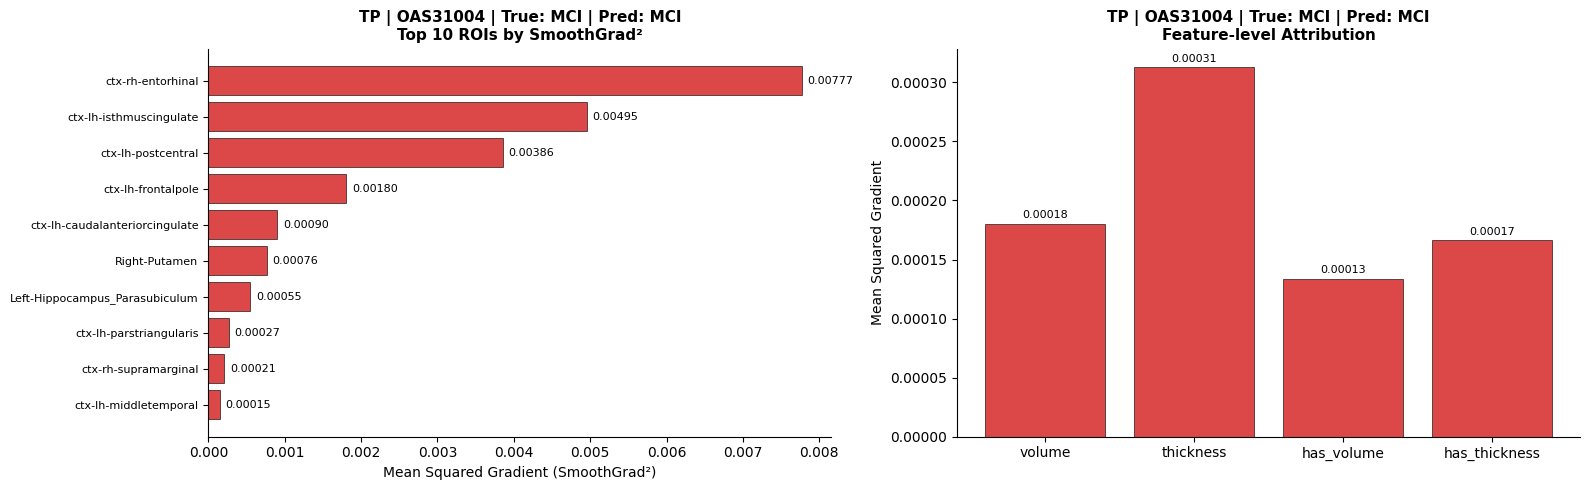

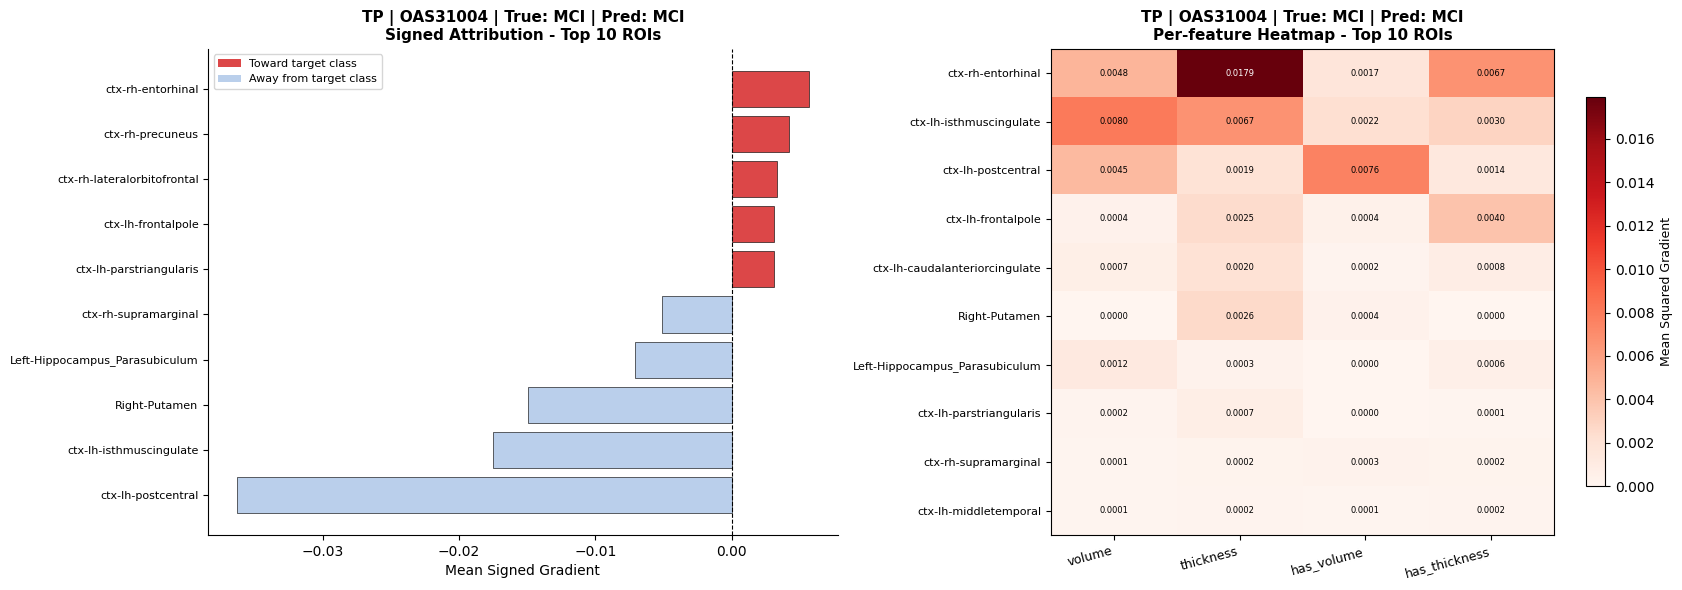


--------------------------------------------------------------------------------

TN | OAS30723 | True: CN | Pred: CN
  Top 10 ROIs (SmoothGrad²):
    01. Left-Hippocampus_Parasubiculum                 0.007427
    02. ctx-rh-superiorparietal                        0.005052
    03. ctx-lh-posteriorcingulate                      0.003195
    04. Right-Anterior                                 0.001633
    05. ctx-lh-cuneus                                  0.001552
    06. ctx-lh-precuneus                               0.001418
    07. Right-Ventral_Anterior                         0.001131
    08. Left-Hippocampus_Hippocampal_fissure           0.001130
    09. ctx-rh-paracentral                             0.000881
    10. Right-Ventral_Latero_Ventral                   0.000880
  Feature importance: {'volume': np.float32(0.000209), 'thickness': np.float32(0.000243), 'has_volume': np.float32(0.000529), 'has_thickness': np.float32(0.00048)}


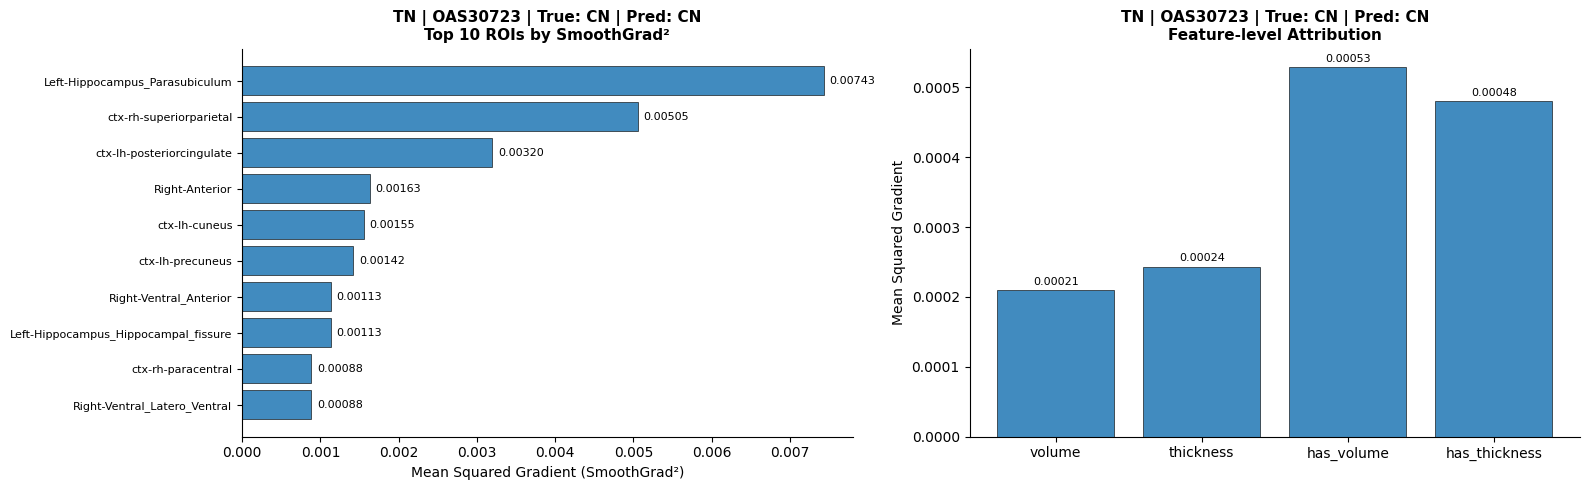

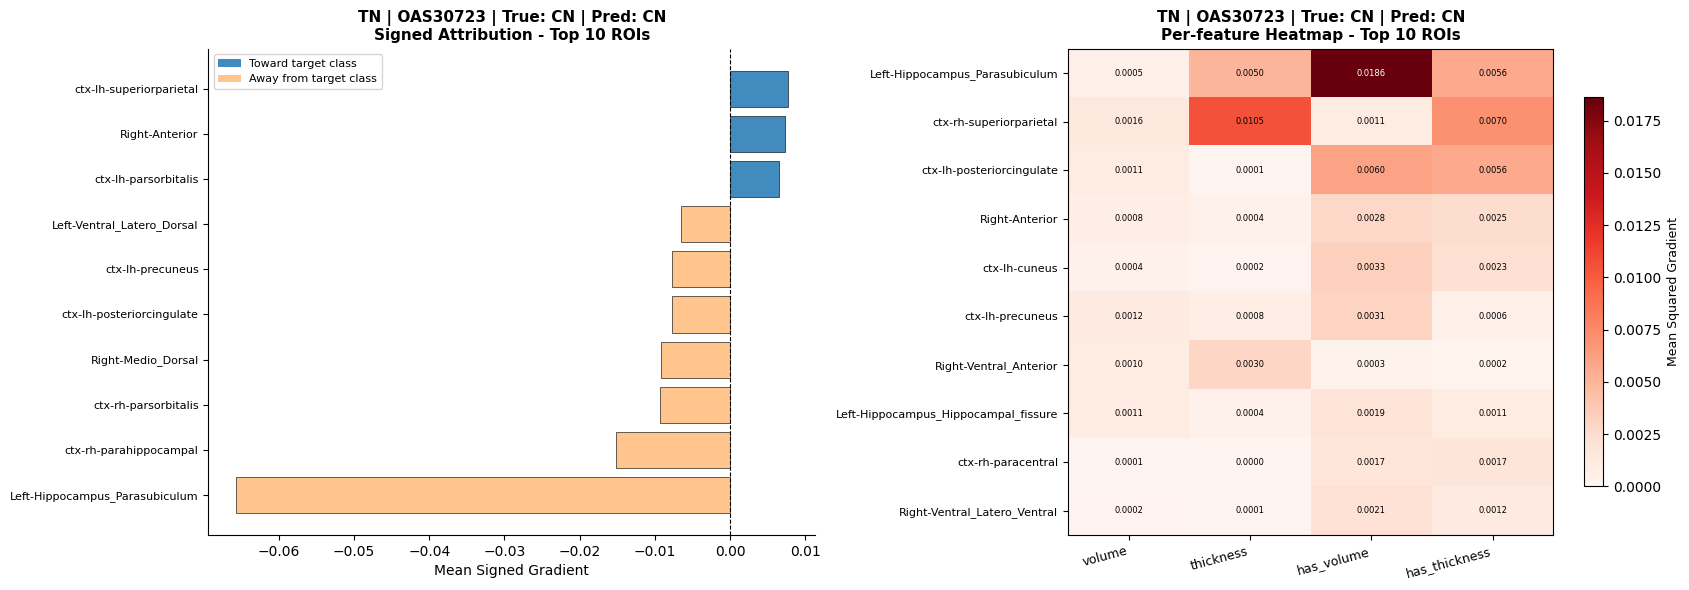


--------------------------------------------------------------------------------

FP | OAS30443 | True: CN | Pred: MCI
  Top 10 ROIs (SmoothGrad²):
    01. Right-Amygdala                                 0.010660
    02. Right-Pulvinar                                 0.004373
    03. Right-Putamen                                  0.001361
    04. ctx-rh-parsopercularis                         0.000860
    05. ctx-rh-medialorbitofrontal                     0.000691
    06. ctx-rh-rostralanteriorcingulate                0.000621
    07. ctx-rh-parsorbitalis                           0.000611
    08. ctx-lh-rostralmiddlefrontal                    0.000489
    09. ctx-lh-parstriangularis                        0.000282
    10. Left-Accumbens_area                            0.000231
  Feature importance: {'volume': np.float32(0.000246), 'thickness': np.float32(0.000315), 'has_volume': np.float32(0.000101), 'has_thickness': np.float32(0.000205)}


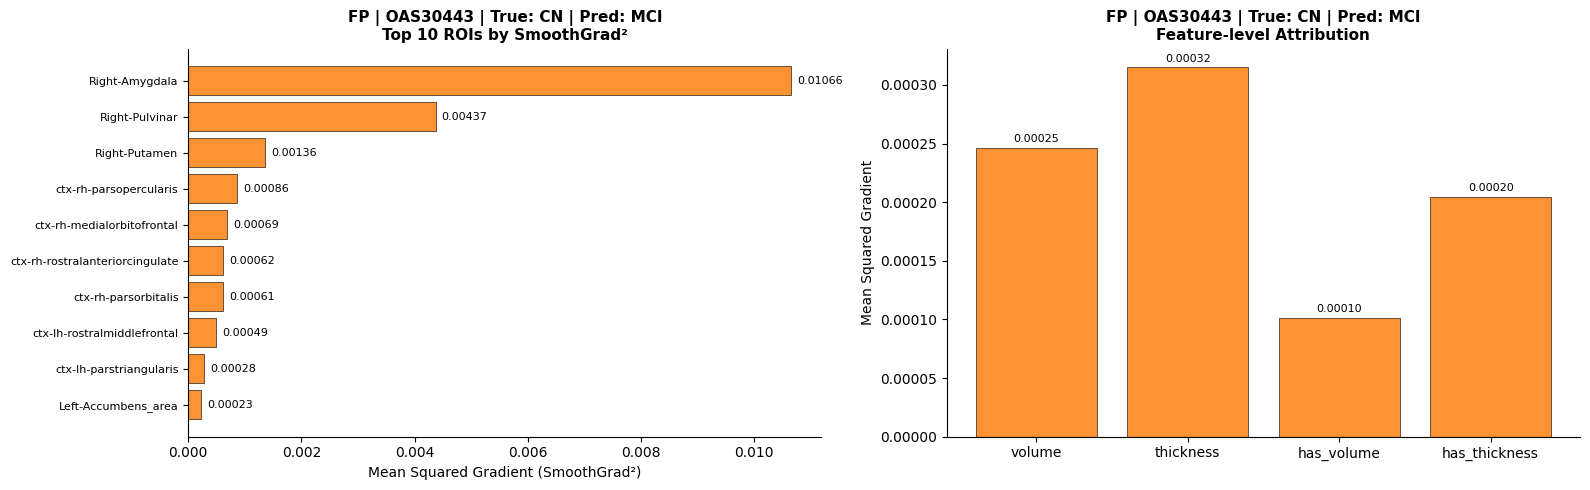

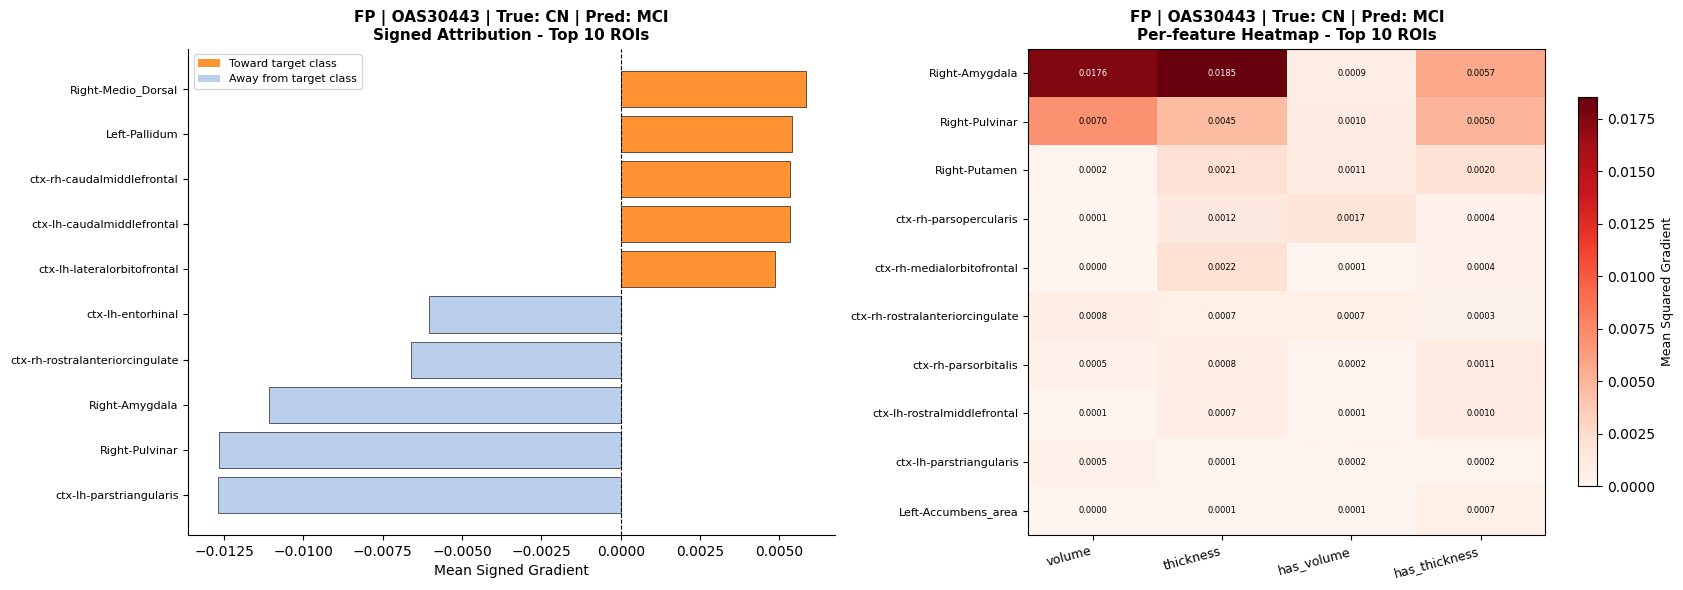


--------------------------------------------------------------------------------

FN | OAS31050 | True: MCI | Pred: CN
  Top 10 ROIs (SmoothGrad²):
    01. ctx-rh-pericalcarine                           0.018763
    02. ctx-rh-fusiform                                0.013062
    03. ctx-lh-isthmuscingulate                        0.012165
    04. Brain_Stem-SCP                                 0.006489
    05. Right-VentralDC                                0.005707
    06. ctx-lh-precentral                              0.003282
    07. ctx-lh-postcentral                             0.002812
    08. ctx-lh-caudalanteriorcingulate                 0.002556
    09. Left-Caudate                                   0.002448
    10. ctx-rh-parsopercularis                         0.002429
  Feature importance: {'volume': np.float32(0.00084), 'thickness': np.float32(0.001053), 'has_volume': np.float32(0.000639), 'has_thickness': np.float32(0.001259)}


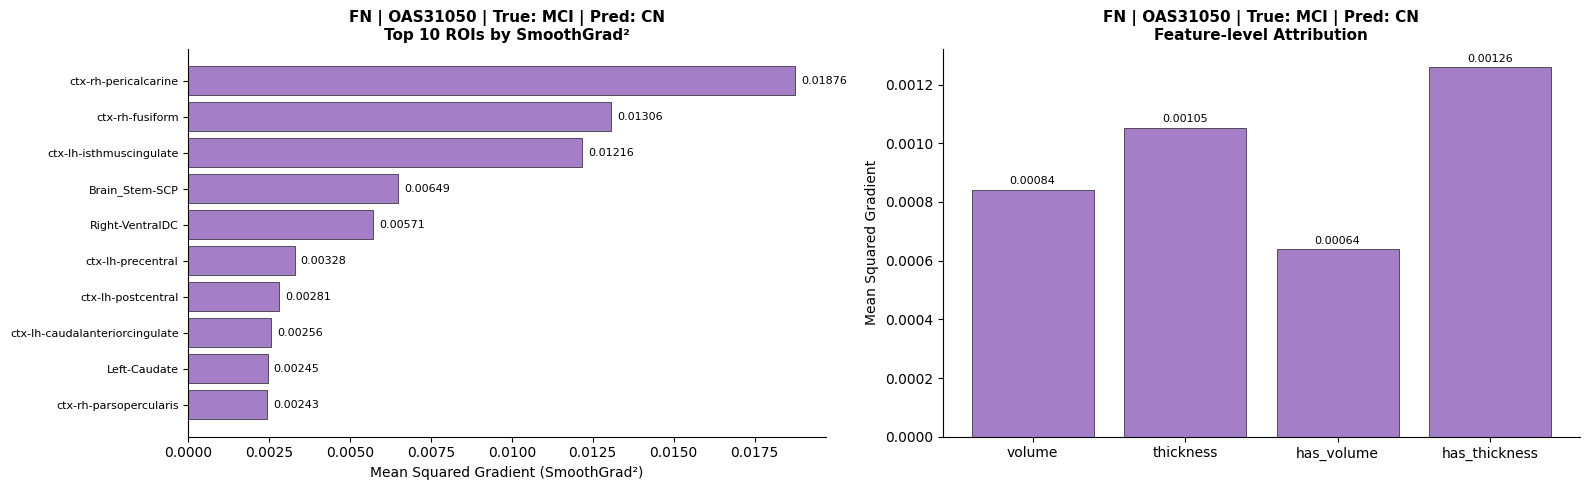

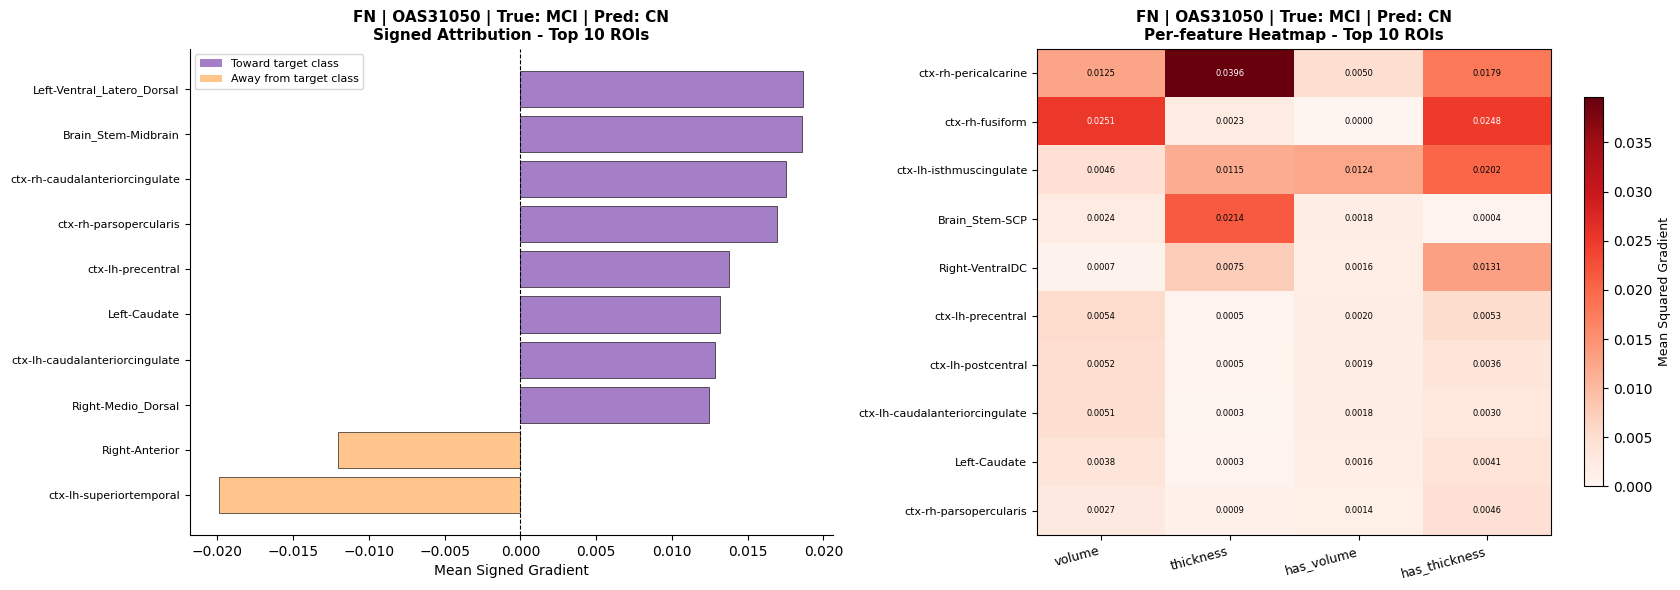

In [10]:
def run_single_subject(g, true_l, pred_l, tag, n_samples=100, noise_level=0.1):
    target_class = pred_l
    attr_signed, attr_sq = run_smoothgrad(
        g, target_class, n_samples=n_samples, noise_level=noise_level
    )

    node_imp = attr_sq.mean(axis=1)      # (num_nodes,) - collapsed over features
    feat_imp = attr_sq.mean(axis=0)      # (4,) - collapsed over nodes

    _, top_names, top_scores = get_top_nodes(node_imp)
    title_base = (f"{tag} | {g.subject_id} | "
                  f"True: {CLASS_NAMES[true_l]} | Pred: {CLASS_NAMES[pred_l]}")

    print(f'\n{title_base}')
    print('  Top 10 ROIs (SmoothGrad²):')
    for rank, (name, score) in enumerate(zip(top_names, top_scores)):
        print(f'    {rank+1:02d}. {name:<45s}  {score:.6f}')
    print('  Feature importance:', dict(zip(NODE_FEATURE_NAMES, feat_imp.round(6))))

    c     = OUTCOME_COLORS[tag]
    c_neg = '#aec7e8' if pred_l == 1 else '#ffbb78'

    # figure 1: top node bar + feature bar
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_top_nodes(axes[0], top_names, top_scores,
                   f'{title_base}\nTop 10 ROIs by SmoothGrad²', c)
    plot_feature_bar(axes[1], feat_imp,
                     f'{title_base}\nFeature-level Attribution', c)
    plt.tight_layout()
    plt.show()

    # figure 2: signed bar + heatmap
    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    plot_signed_bar(axes[0], attr_signed,
                    f'{title_base}\nSigned Attribution - Top 10 ROIs', c, c_neg)
    plot_feature_heatmap(axes[1], attr_sq,
                         f'{title_base}\nPer-feature Heatmap - Top 10 ROIs')
    plt.tight_layout()
    plt.show()

    return attr_signed, attr_sq, node_imp, feat_imp


case_subjects = {}
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    g, true_l, pred_l, _ = pool[0]
    print(f'\n{"-"*80}')
    attr_signed, attr_sq, node_imp, feat_imp = run_single_subject(g, true_l, pred_l, tag)
    case_subjects[tag] = {
        'graph': g, 'true': true_l, 'pred': pred_l,
        'attr_signed': attr_signed, 'attr_sq': attr_sq,
        'node_imp': node_imp, 'feat_imp': feat_imp,
    }

### Population analysis per outcome group

In [11]:
def run_population(result_pool, pred_label, tag, n_samples=100, noise_level=0.1):
    '''
    Runs SmoothGrad on every subject in result_pool
    target_class = pred_label (explain the predicted class)

    Returns
    mean_node_imp : (num_nodes,)  - mean SmoothGrad² per node
    mean_feat_imp : (4,)          - mean SmoothGrad² per feature
    '''
    all_node_imp = []
    all_feat_imp = []

    for i, (g, true, pred, _) in enumerate(result_pool):
        _, attr_sq = run_smoothgrad(
            g, pred_label, n_samples=n_samples, noise_level=noise_level
        )
        all_node_imp.append(attr_sq.mean(axis=1))   # (num_nodes,)
        all_feat_imp.append(attr_sq.mean(axis=0))   # (4,)
        if (i + 1) % 10 == 0 or (i + 1) == len(result_pool):
            print(f'  {tag}: {i+1}/{len(result_pool)} subjects done')

    mean_node_imp = np.stack(all_node_imp).mean(axis=0)
    mean_feat_imp = np.stack(all_feat_imp).mean(axis=0)
    print(f'{tag} (n={len(result_pool)}): population SmoothGrad done.')
    return mean_node_imp, mean_feat_imp


pop_results = {}
for tag, pool, pred_l in [
    ('TP', TP, 1), ('TN', TN, 0), ('FP', FP, 1), ('FN', FN, 0)
]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    mean_node, mean_feat = run_population(pool, pred_l, tag)
    pop_results[tag] = {'mean_node': mean_node, 'mean_feat': mean_feat, 'n': len(pool)}

  TP: 10/14 subjects done
  TP: 14/14 subjects done
TP (n=14): population SmoothGrad done.
  TN: 10/87 subjects done
  TN: 20/87 subjects done
  TN: 30/87 subjects done
  TN: 40/87 subjects done
  TN: 50/87 subjects done
  TN: 60/87 subjects done
  TN: 70/87 subjects done
  TN: 80/87 subjects done
  TN: 87/87 subjects done
TN (n=87): population SmoothGrad done.
  FP: 10/18 subjects done
  FP: 18/18 subjects done
FP (n=18): population SmoothGrad done.
  FN: 8/8 subjects done
FN (n=8): population SmoothGrad done.


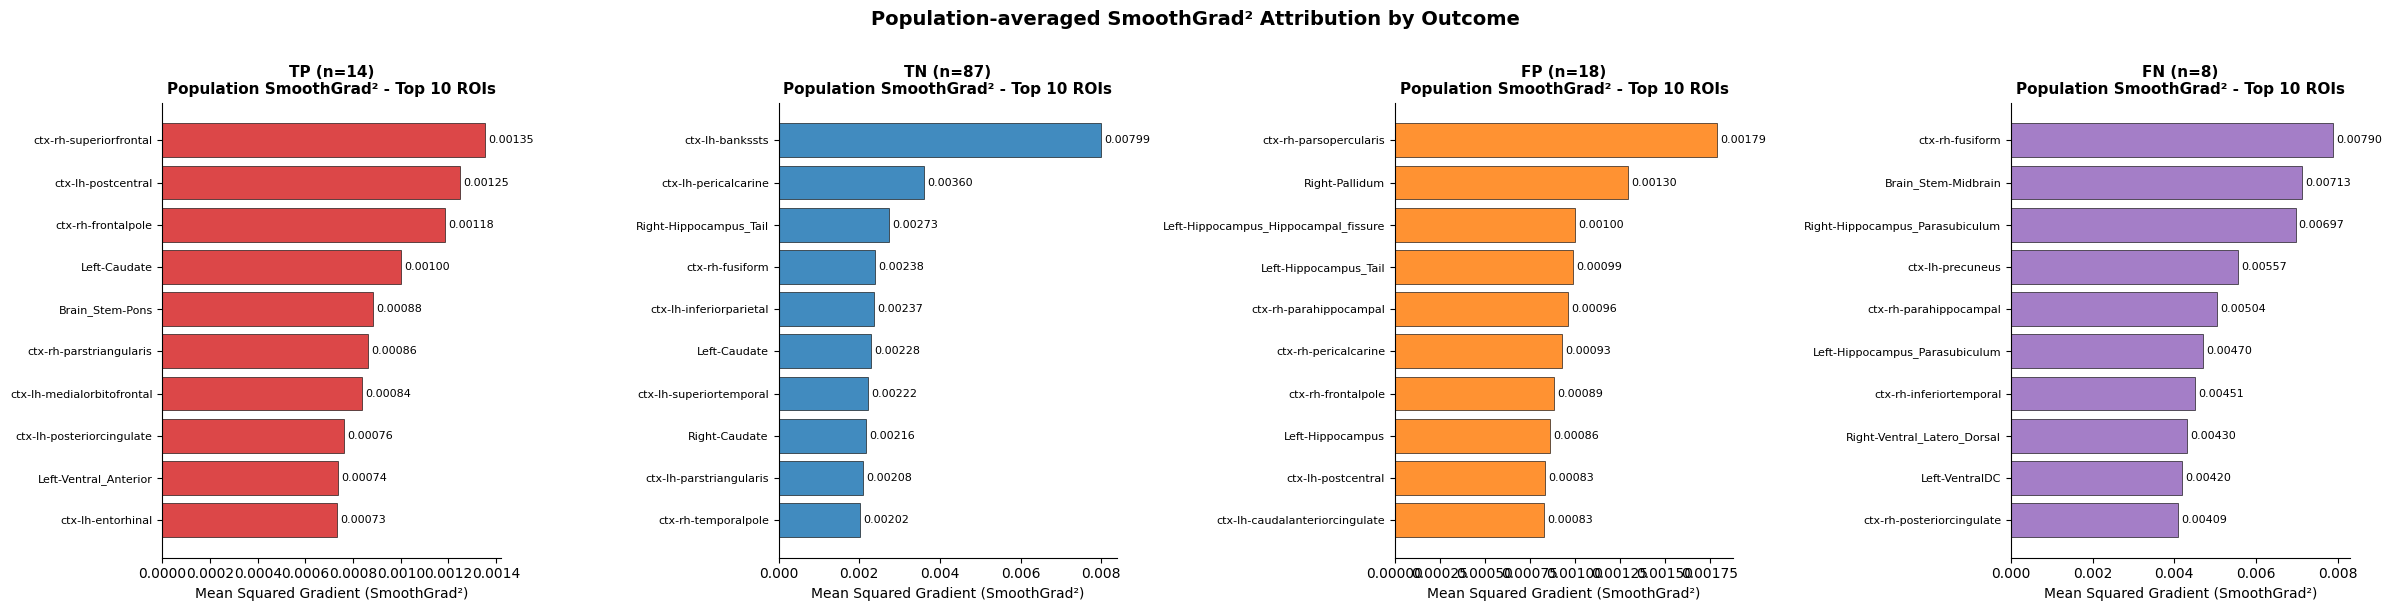

In [12]:
# top ROIs per outcome group
available_tags = [t for t in ['TP', 'TN', 'FP', 'FN'] if t in pop_results]

fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
if len(available_tags) == 1:
    axes = [axes]

for ax, tag in zip(axes, available_tags):
    r = pop_results[tag]
    _, top_names, top_scores = get_top_nodes(r['mean_node'])
    plot_top_nodes(ax, top_names, top_scores,
                   f"{tag} (n={r['n']})\nPopulation SmoothGrad² - Top 10 ROIs",
                   OUTCOME_COLORS[tag])

plt.suptitle('Population-averaged SmoothGrad² Attribution by Outcome',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

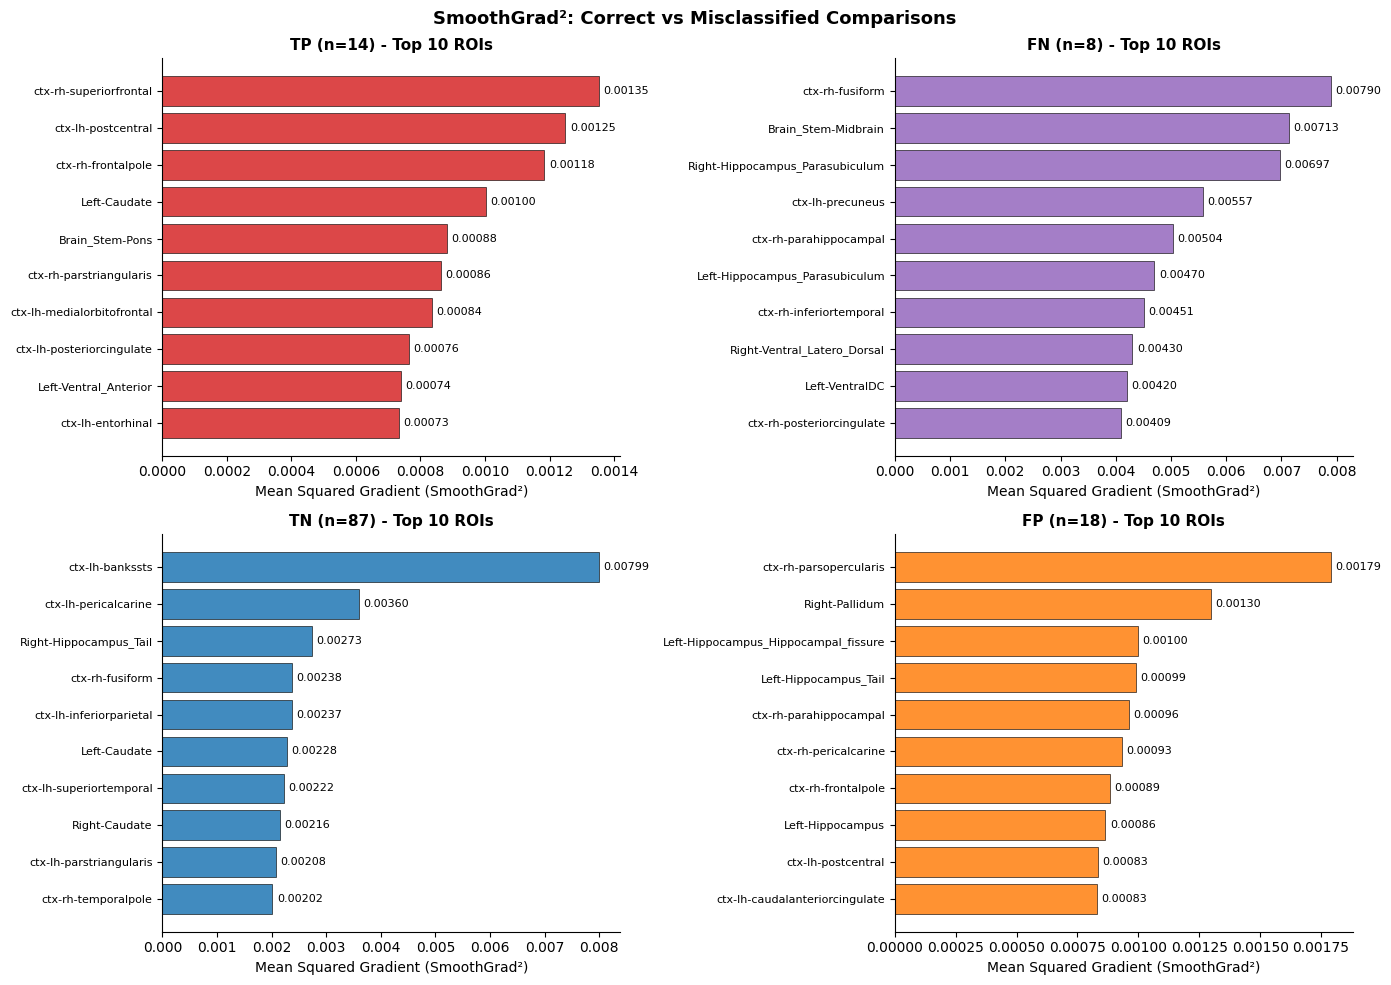

In [13]:
# correct vs misclassified comparison (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [('TP', 0, 0), ('FN', 0, 1), ('TN', 1, 0), ('FP', 1, 1)]
for tag, row, col in pairs:
    if tag not in pop_results:
        axes[row, col].set_visible(False)
        continue
    r = pop_results[tag]
    _, top_names, top_scores = get_top_nodes(r['mean_node'])
    plot_top_nodes(axes[row, col], top_names, top_scores,
                   f"{tag} (n={r['n']}) - Top 10 ROIs", OUTCOME_COLORS[tag])

plt.suptitle('SmoothGrad²: Correct vs Misclassified Comparisons',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

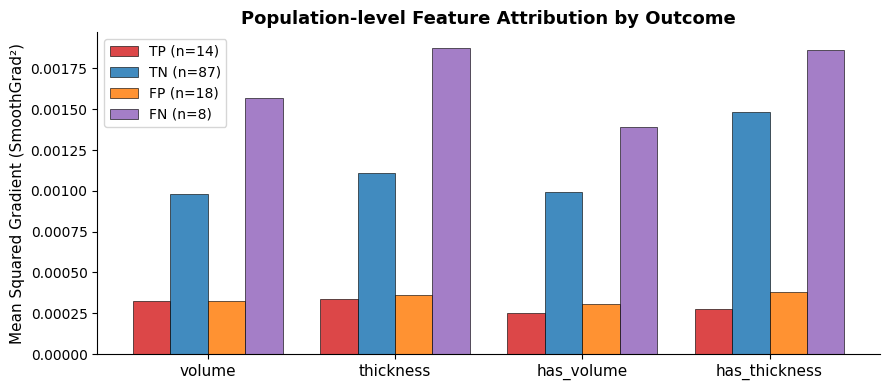


Feature attribution summary (mean squared gradient):
                   volume     thickness    has_volume  has_thickness
TP               0.000323      0.000335      0.000252      0.000277
TN               0.000981      0.001111      0.000992      0.001482
FP               0.000324      0.000362      0.000307      0.000378
FN               0.001569      0.001878      0.001389      0.001864


In [14]:
# feature attribution grouped bar
# answers: which of the 4 node features does the model rely on, per outcome group?
x     = np.arange(4)
width = 0.8 / len(available_tags)

fig, ax = plt.subplots(figsize=(9, 4))
for i, tag in enumerate(available_tags):
    r      = pop_results[tag]
    offset = (i - len(available_tags) / 2 + 0.5) * width
    ax.bar(x + offset, r['mean_feat'], width,
           label=f"{tag} (n={r['n']})",
           color=OUTCOME_COLORS[tag], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(NODE_FEATURE_NAMES, fontsize=11)
ax.set_ylabel('Mean Squared Gradient (SmoothGrad²)', fontsize=11)
ax.set_title('Population-level Feature Attribution by Outcome',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nFeature attribution summary (mean squared gradient):')
print(f'{"":<12}', '  '.join(f"{n:>12}" for n in NODE_FEATURE_NAMES))
for tag in available_tags:
    vals = pop_results[tag]['mean_feat']
    print(f'{tag:<12}', '  '.join(f"{v:>12.6f}" for v in vals))

### Per class population analysis

In [15]:
# Per-class population analysis

CLASS_COLORS = {0: '#1f77b4', 1: '#d62728'}   # CN: blue, MCI: red

# split test set by TRUE label
class_pools = {0: [], 1: []}
for g, true, pred, score in results:
    class_pools[true].append((g, true, pred, score))

print(f'CN  (true=0): {len(class_pools[0])} subjects')
print(f'MCI (true=1): {len(class_pools[1])} subjects')

def run_class_population(result_pool, tag, n_samples=100, noise_level=0.1):
    '''
    Runs SmoothGrad on every subject in result_pool.
    target_class = predicted class for each subject (explain what the model decided).
    Aggregates squared gradients (for ranking) and signed gradients w.r.t. MCI

    Returns
    mean_node_imp   : (num_nodes,)         - mean SmoothGrad² per node
    mean_feat_imp   : (4,)                 - mean SmoothGrad² per feature
    mean_node_signed_mci : (num_nodes,)    - mean signed gradient w.r.t. MCI logit,
                                             averaged across features and subjects
    mean_attr_sq    : (num_nodes, 4)       - mean SmoothGrad² per (node, feature)
    '''
    all_node_imp        = []
    all_feat_imp        = []
    all_node_signed_mci = []
    all_attr_sq         = []

    for i, (g, true, pred, _) in enumerate(result_pool):
        # SmoothGrad² (for magnitude/ranking) explained at predicted class
        _, attr_sq = run_smoothgrad(
            g, pred, n_samples=n_samples, noise_level=noise_level
        )
        # Signed gradients always w.r.t. MCI logit (class 1) so positive = toward MCI
        attr_signed_mci, _ = run_smoothgrad(
            g, target_class=1, n_samples=n_samples, noise_level=noise_level
        )

        all_node_imp.append(attr_sq.mean(axis=1))               # (num_nodes,)
        all_feat_imp.append(attr_sq.mean(axis=0))               # (4,)
        all_node_signed_mci.append(attr_signed_mci.mean(axis=1))  # (num_nodes,)
        all_attr_sq.append(attr_sq)                             # (num_nodes, 4)

        if (i + 1) % 10 == 0 or (i + 1) == len(result_pool):
            print(f'  {tag}: {i+1}/{len(result_pool)} subjects done')

    mean_node_imp        = np.stack(all_node_imp).mean(axis=0)
    mean_feat_imp        = np.stack(all_feat_imp).mean(axis=0)
    mean_node_signed_mci = np.stack(all_node_signed_mci).mean(axis=0)
    mean_attr_sq         = np.stack(all_attr_sq).mean(axis=0)
    print(f'{tag} (n={len(result_pool)}): per-class SmoothGrad done.')
    return mean_node_imp, mean_feat_imp, mean_node_signed_mci, mean_attr_sq


class_results = {}
for cls_idx, cls_name in CLASS_NAMES.items():
    pool = class_pools[cls_idx]
    if not pool:
        print(f'{cls_name}: no subjects, skipping.')
        continue
    mean_node, mean_feat, mean_signed_mci, mean_attr_sq = run_class_population(pool, cls_name)
    class_results[cls_name] = {
        'mean_node':        mean_node,
        'mean_feat':        mean_feat,
        'mean_signed_mci':  mean_signed_mci,
        'mean_attr_sq':     mean_attr_sq,
        'n':                len(pool),
        'color':            CLASS_COLORS[cls_idx],
    }

CN  (true=0): 105 subjects
MCI (true=1): 22 subjects
  CN: 10/105 subjects done
  CN: 20/105 subjects done
  CN: 30/105 subjects done
  CN: 40/105 subjects done
  CN: 50/105 subjects done
  CN: 60/105 subjects done
  CN: 70/105 subjects done
  CN: 80/105 subjects done
  CN: 90/105 subjects done
  CN: 100/105 subjects done
  CN: 105/105 subjects done
CN (n=105): per-class SmoothGrad done.
  MCI: 10/22 subjects done
  MCI: 20/22 subjects done
  MCI: 22/22 subjects done
MCI (n=22): per-class SmoothGrad done.


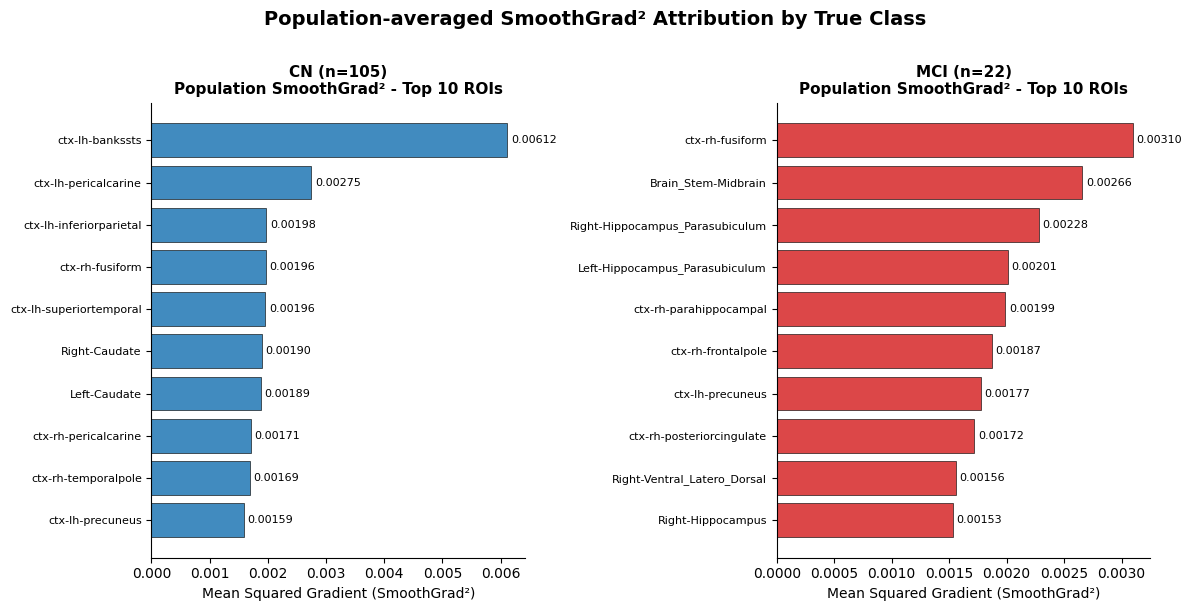

In [16]:
# Top ROIs per class (SmoothGrad²)
available_classes = [c for c in ['CN', 'MCI'] if c in class_results]

fig, axes = plt.subplots(1, len(available_classes),
                         figsize=(6 * len(available_classes), 6))
if len(available_classes) == 1:
    axes = [axes]

for ax, cls_name in zip(axes, available_classes):
    r = class_results[cls_name]
    _, top_names, top_scores = get_top_nodes(r['mean_node'])
    plot_top_nodes(ax, top_names, top_scores,
                   f"{cls_name} (n={r['n']})\nPopulation SmoothGrad² - Top 10 ROIs",
                   r['color'])

plt.suptitle('Population-averaged SmoothGrad² Attribution by True Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

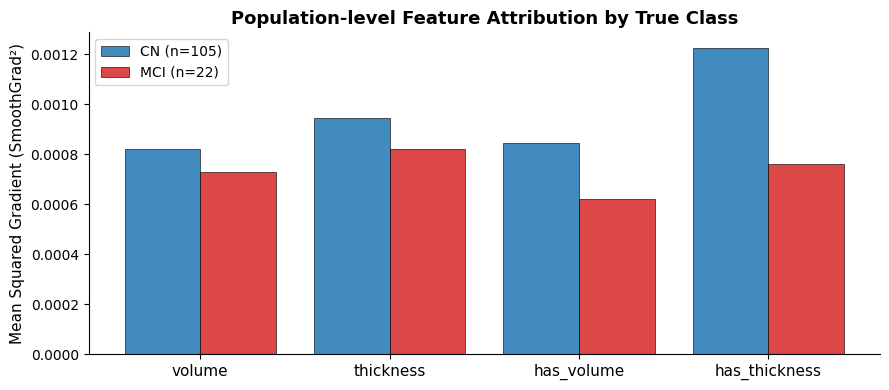


Feature attribution summary by class (mean squared gradient):
                   volume     thickness    has_volume  has_thickness
CN               0.000821      0.000947      0.000847      0.001227
MCI              0.000731      0.000823      0.000621      0.000760


In [17]:
# Per-class feature attribution
x     = np.arange(4)
width = 0.8 / len(available_classes)

fig, ax = plt.subplots(figsize=(9, 4))
for i, cls_name in enumerate(available_classes):
    r      = class_results[cls_name]
    offset = (i - len(available_classes) / 2 + 0.5) * width
    ax.bar(x + offset, r['mean_feat'], width,
           label=f"{cls_name} (n={r['n']})",
           color=r['color'], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(NODE_FEATURE_NAMES, fontsize=11)
ax.set_ylabel('Mean Squared Gradient (SmoothGrad²)', fontsize=11)
ax.set_title('Population-level Feature Attribution by True Class',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nFeature attribution summary by class (mean squared gradient):')
print(f'{"":<12}', '  '.join(f"{n:>12}" for n in NODE_FEATURE_NAMES))
for cls_name in available_classes:
    vals = class_results[cls_name]['mean_feat']
    print(f'{cls_name:<12}', '  '.join(f"{v:>12.6f}" for v in vals))

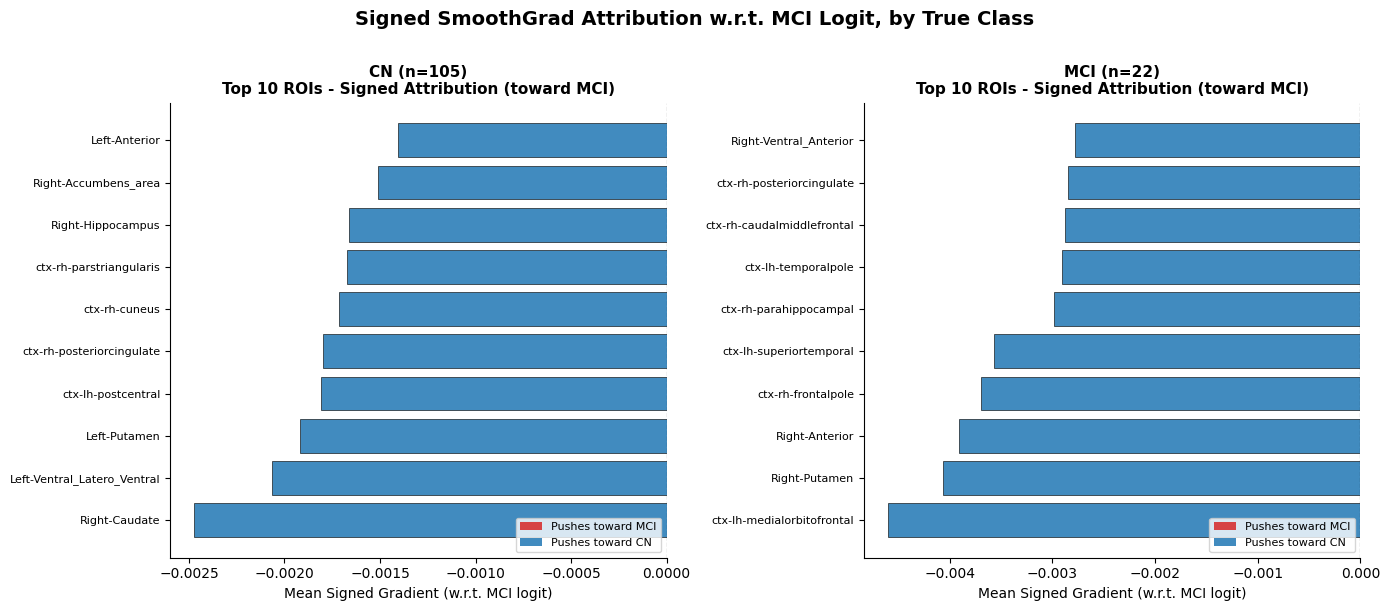


Signed attribution toward MCI (positive = pro-MCI, negative = pro-CN):

  CN subjects (n=105):
    Top 5 pro-MCI ROIs:
      + ctx-rh-bankssts                               +0.001115
      + ctx-lh-medialorbitofrontal                    +0.000731
      + ctx-lh-caudalmiddlefrontal                    +0.000678
      + ctx-lh-temporalpole                           +0.000579
      + Right-Medio_Dorsal                            +0.000576
    Top 5 pro-CN ROIs:
      - Right-Caudate                                 -0.002474
      - Left-Ventral_Latero_Ventral                   -0.002065
      - Left-Putamen                                  -0.001916
      - ctx-lh-postcentral                            -0.001810
      - ctx-rh-posteriorcingulate                     -0.001796

  MCI subjects (n=22):
    Top 5 pro-MCI ROIs:
      + Brain_Stem-Pons                               +0.001801
      + ctx-lh-rostralmiddlefrontal                   +0.001523
      + ctx-rh-lateralorbitofrontal      

In [18]:
# Signed analysis w.r.t. MCI class

MCI_POS_COLOR = '#d62728'   # toward MCI
MCI_NEG_COLOR = '#1f77b4'   # toward CN

def plot_signed_bar_mci(ax, node_signed_mci, title, top_n=10):
    '''
    Horizontal bar of signed mean gradients per node, w.r.t. MCI logit.
    Ranked by |signed value| so most influential nodes appear regardless of sign.
    '''
    top_idx    = np.argsort(np.abs(node_signed_mci))[::-1][:top_n]
    top_names  = [node_labels[i] for i in top_idx]
    top_signed = node_signed_mci[top_idx]
    order      = np.argsort(top_signed)
    top_names  = [top_names[i] for i in order]
    top_signed = top_signed[order]
    colors     = [MCI_POS_COLOR if s > 0 else MCI_NEG_COLOR for s in top_signed]
    ax.barh(top_names, top_signed, color=colors, alpha=0.85,
            edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean Signed Gradient (w.r.t. MCI logit)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    legend_elements = [
        Patch(facecolor=MCI_POS_COLOR, alpha=0.85, label='Pushes toward MCI'),
        Patch(facecolor=MCI_NEG_COLOR, alpha=0.85, label='Pushes toward CN'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')


# side-by-side: top contributors per class, signed w.r.t. MCI
fig, axes = plt.subplots(1, len(available_classes),
                         figsize=(7 * len(available_classes), 6))
if len(available_classes) == 1:
    axes = [axes]

for ax, cls_name in zip(axes, available_classes):
    r = class_results[cls_name]
    plot_signed_bar_mci(
        ax, r['mean_signed_mci'],
        f"{cls_name} (n={r['n']})\nTop 10 ROIs - Signed Attribution (toward MCI)"
    )

plt.suptitle('Signed SmoothGrad Attribution w.r.t. MCI Logit, by True Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# textual summary: which nodes are pro-MCI / pro-CN in each true class
print('\nSigned attribution toward MCI (positive = pro-MCI, negative = pro-CN):')
for cls_name in available_classes:
    signed = class_results[cls_name]['mean_signed_mci']
    print(f'\n  {cls_name} subjects (n={class_results[cls_name]["n"]}):')
    pro_mci = np.argsort(signed)[::-1][:5]
    pro_cn  = np.argsort(signed)[:5]
    print('    Top 5 pro-MCI ROIs:')
    for i in pro_mci:
        print(f'      + {node_labels[i]:<45s} {signed[i]:+.6f}')
    print('    Top 5 pro-CN ROIs:')
    for i in pro_cn:
        print(f'      - {node_labels[i]:<45s} {signed[i]:+.6f}')

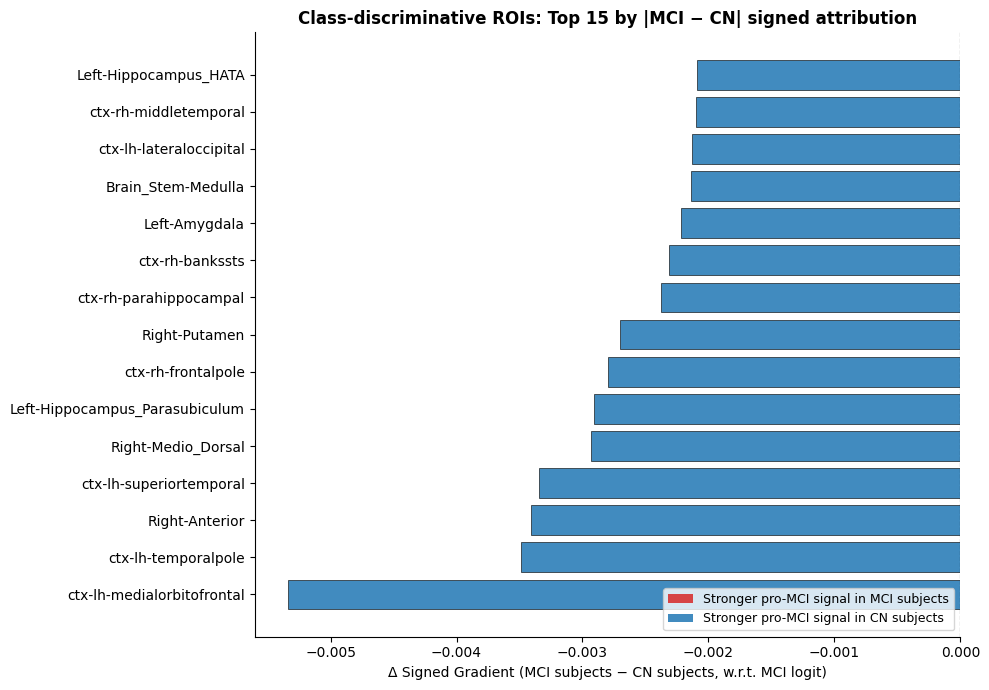

In [19]:
# MCI vs CN - where do the two populations diverge

if 'CN' in class_results and 'MCI' in class_results:
    diff = class_results['MCI']['mean_signed_mci'] - class_results['CN']['mean_signed_mci']

    top_idx    = np.argsort(np.abs(diff))[::-1][:15]
    top_names  = [node_labels[i] for i in top_idx]
    top_diff   = diff[top_idx]
    order      = np.argsort(top_diff)
    top_names  = [top_names[i] for i in order]
    top_diff   = top_diff[order]
    colors     = [MCI_POS_COLOR if d > 0 else MCI_NEG_COLOR for d in top_diff]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_names, top_diff, color=colors, alpha=0.85,
            edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Δ Signed Gradient (MCI subjects − CN subjects, w.r.t. MCI logit)',
                  fontsize=10)
    ax.set_title('Class-discriminative ROIs: Top 15 by |MCI − CN| signed attribution',
                 fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend_elements = [
        Patch(facecolor=MCI_POS_COLOR, alpha=0.85,
              label='Stronger pro-MCI signal in MCI subjects'),
        Patch(facecolor=MCI_NEG_COLOR, alpha=0.85,
              label='Stronger pro-MCI signal in CN subjects'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('Need both CN and MCI groups for difference plot; skipping.')